<a href="https://colab.research.google.com/github/quinterogilalejandro-wq/13-Implementaci-n-de-un-Autoencoder-en-una-Red-Denoising-usando-el-dataset-MNIST-/blob/main/Semana_12_Ejercicio_de_Aplicaci%C3%B3n_(Caso_de_estudio_RRHH)_ML_Supervisado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


   DENOISING AUTOENCODER — MNIST
   Dispositivo    : cpu
   Latent dim     : 64
   Noise factor   : 0.4
   Epocas max.    : 40
   Learning rate  : 0.001

  [1/5] Cargando dataset MNIST...
     Entrenamiento : 60,000 imagenes
     Prueba        : 10,000 imagenes
     Mini-lotes    : 235 train | 40 test

  [2/5] Verificando preprocesamiento...


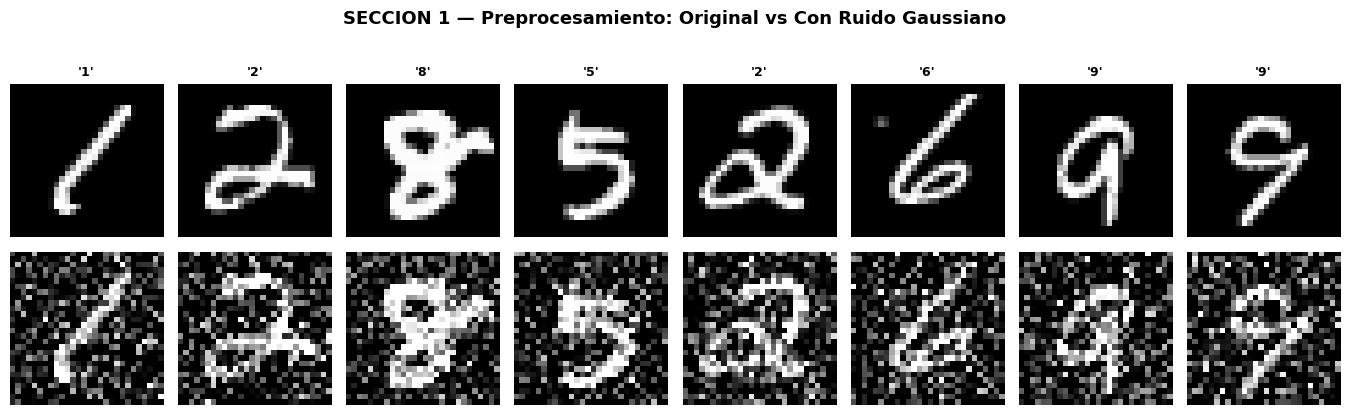

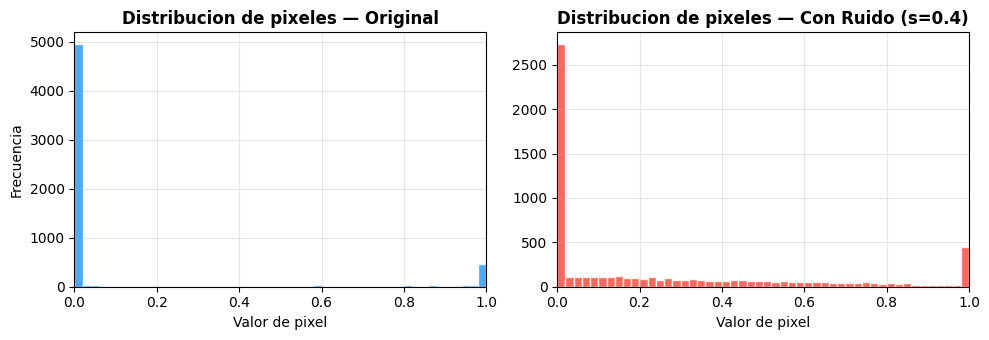

  Guardado: 01a_preprocesamiento_imagenes.png
  Guardado: 01b_histograma_pixeles.png

  [3/5] Arquitectura del Autoencoder
  --------------------------------------------------

  ENCODER:
Encoder(
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Linear(in_features=512, out_features=256, bias=True)
    (4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): Linear(in_features=128, out_features=64, bias=True)
    (10): ReLU(inplace=True)
  )
)

  DECODER:
Decoder(
  (net): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU(inplace=True)
    (2): Linear

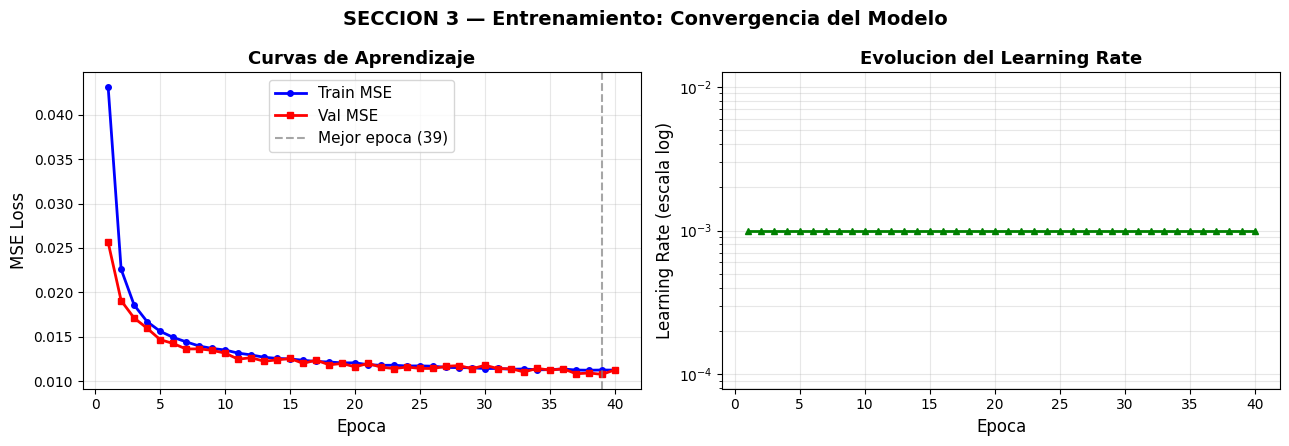

  Guardado: 02_curvas_aprendizaje.png


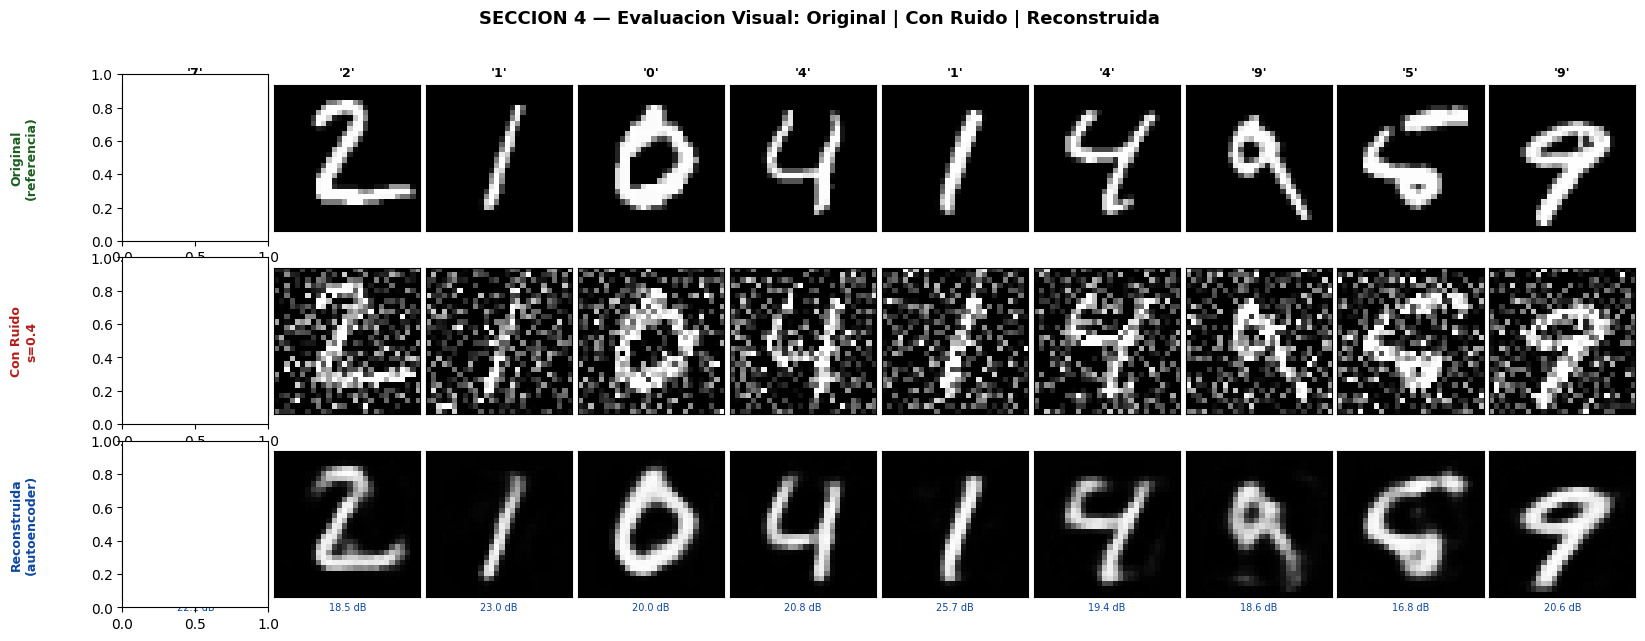

  Guardado: 03_comparacion_reconstruccion.png


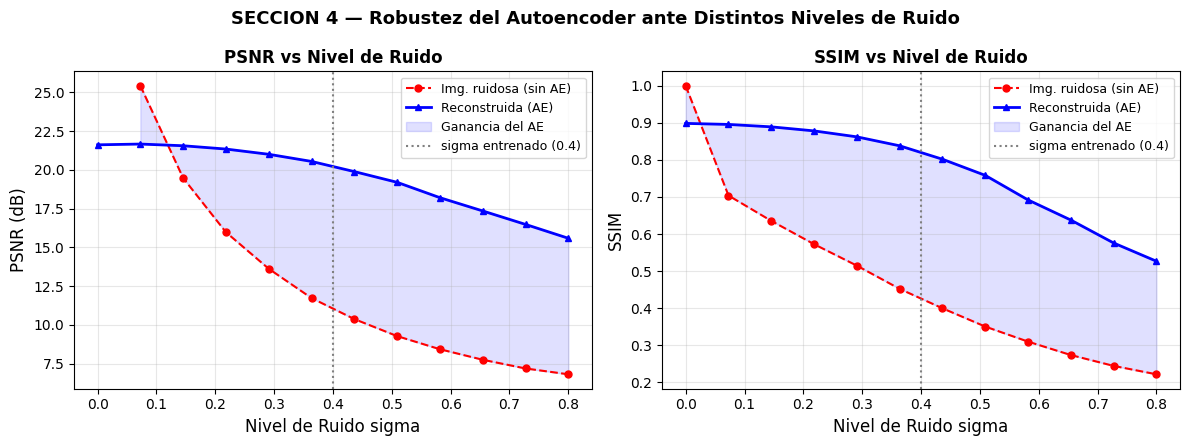

  Guardado: 04_metricas_vs_ruido.png


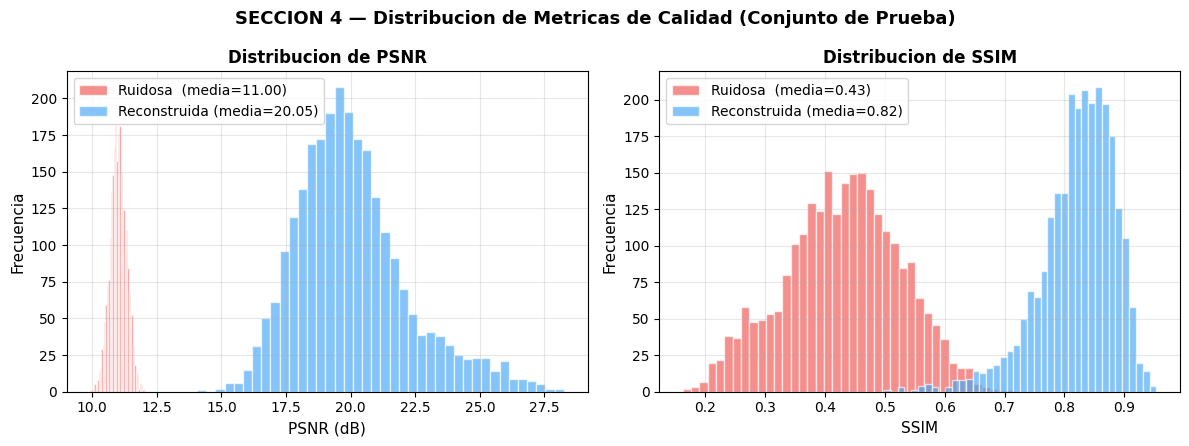

  Guardado: 05_distribucion_metricas.png


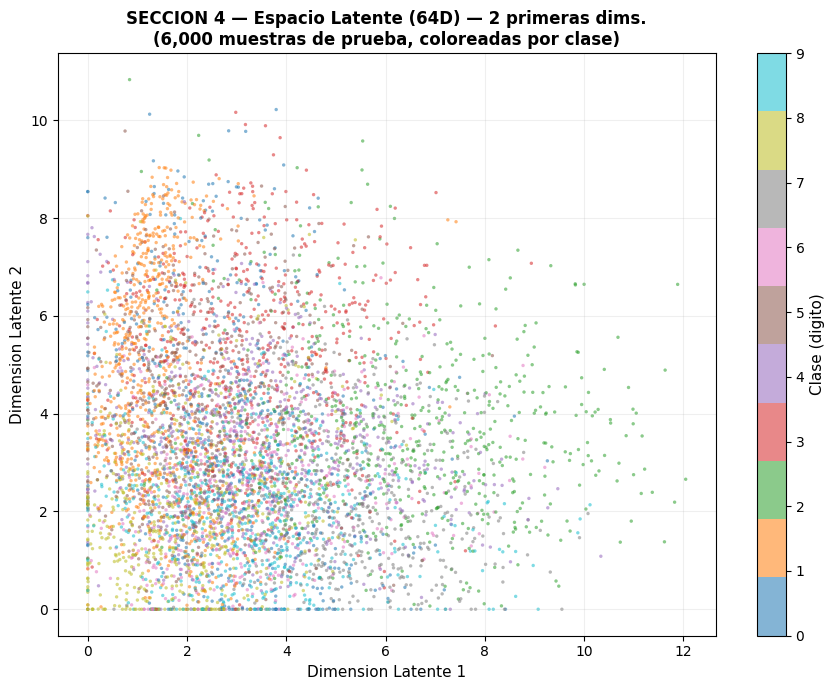

  Guardado: 06_espacio_latente.png


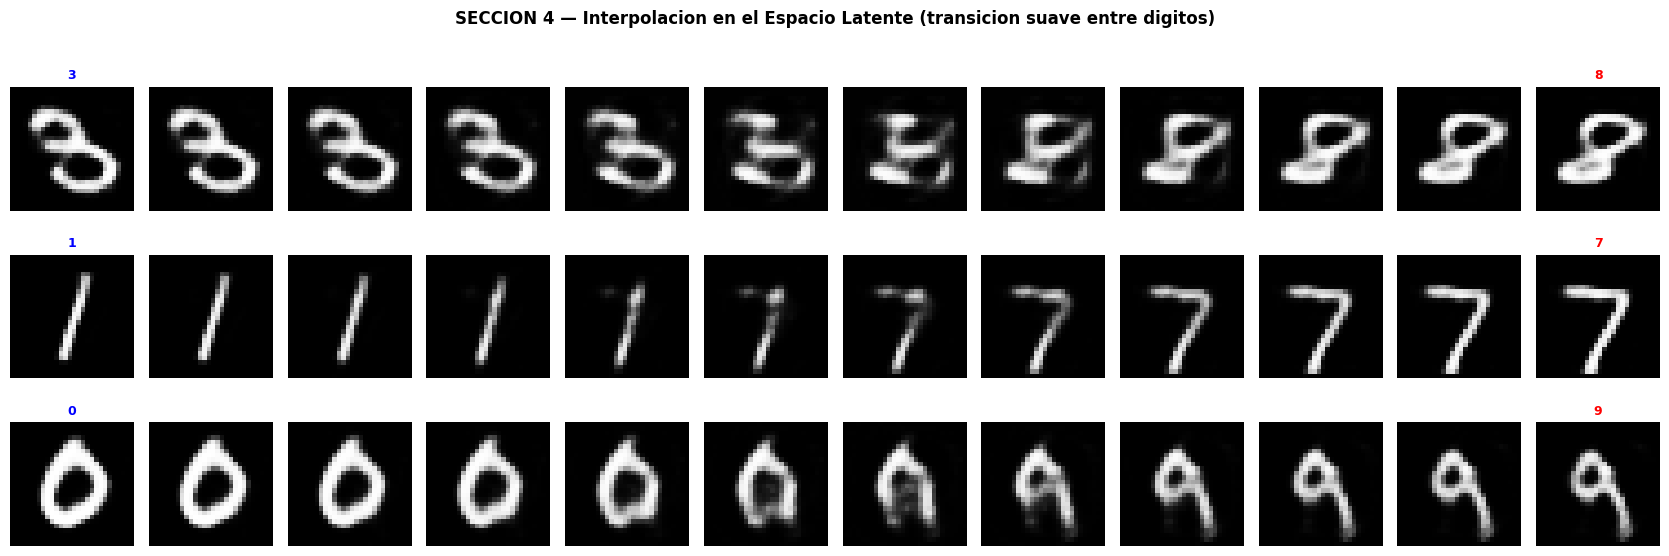

  Guardado: 07_interpolacion_latente.png

  RESUMEN FINAL
  [OK]  best_model.pth                               Pesos del mejor modelo (checkpoint)
  [OK]  01a_preprocesamiento_imagenes.png            Sec.1 — Imagenes original vs ruidosa
  [OK]  01b_histograma_pixeles.png                   Sec.1 — Histograma de pixeles
  [OK]  02_curvas_aprendizaje.png                    Sec.3 — Curvas de aprendizaje + LR
  [OK]  03_comparacion_reconstruccion.png            Sec.4 — Comparacion 3 filas + PSNR
  [OK]  04_metricas_vs_ruido.png                     Sec.4 — PSNR y SSIM vs nivel de ruido
  [OK]  05_distribucion_metricas.png                 Sec.4 — Distribucion de metricas
  [OK]  06_espacio_latente.png                       Sec.4 — Espacio latente 2D
  [OK]  07_interpolacion_latente.png                 Sec.4 — Interpolacion latente

  Hiperparametros utilizados:
     batch_size        : 256
     input_dim         : 784
     latent_dim        : 64
     noise_factor      : 0.4
     epochs       

In [5]:
# =============================================================================
#  DENOISING AUTOENCODER — DATASET MNIST
# =============================================================================

# ── 0. INSTALACIÓN DE DEPENDENCIAS (solo necesaria en Colab) ─────────────────
import subprocess, sys
for pkg in ["torch", "torchvision", "matplotlib", "numpy", "scikit-image"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "--quiet"],
                   check=False)

# ── 1. IMPORTACIONES ──────────────────────────────────────────────────────────
import os, time, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from skimage.metrics import structural_similarity as ssim   # SSIM

# ── 2. REPRODUCIBILIDAD ───────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── 3. DISPOSITIVO ────────────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =============================================================================
#  SECCIÓN 1 — HIPERPARÁMETROS
#  Se centralizan aquí para facilitar experimentación y reproducibilidad.
# =============================================================================

HP = {
    # --- Dataset ---
    "batch_size"   : 256,     # Tamaño de mini-lote
    "input_dim"    : 784,     # 28 x 28 pixeles aplanados

    # --- Arquitectura ---
    "latent_dim"   : 64,      # Dimensión del espacio latente (cuello de botella)
                              # Más alto -> más info preservada; más bajo -> más compresión

    # --- Ruido ---
    "noise_factor" : 0.4,     # Desviación estándar del ruido gaussiano [0, 1]
                              # 0 = sin ruido | 1 = imagen prácticamente irreconocible

    # --- Entrenamiento ---
    "epochs"       : 40,      # Número de épocas
    "lr"           : 1e-3,    # Tasa de aprendizaje inicial (Adam)
    "weight_decay" : 1e-5,    # Regularización L2 (evita sobreajuste)
    "lr_patience"  : 5,       # Épocas sin mejora antes de reducir LR
    "lr_factor"    : 0.5,     # Factor de reducción del LR
    "early_stop"   : 10,      # Detención temprana si no mejora en N épocas
}

# ── Banner informativo ────────────────────────────────────────────────────────
print("\n" + "="*65)
print("   DENOISING AUTOENCODER — MNIST")
print("="*65)
print(f"   Dispositivo    : {DEVICE}")
print(f"   Latent dim     : {HP['latent_dim']}")
print(f"   Noise factor   : {HP['noise_factor']}")
print(f"   Epocas max.    : {HP['epochs']}")
print(f"   Learning rate  : {HP['lr']}")
print("="*65 + "\n")


# =============================================================================
#  SECCIÓN 2 — CARGA Y PREPROCESAMIENTO DEL DATASET
# =============================================================================

# --- 2.1 Transformaciones ---
# Se aplican dos pasos:
#   a) ToTensor(): convierte la imagen PIL a tensor con valores en [0, 1]
#   b) Lambda: aplana el tensor 1x28x28 a un vector 1D de 784 elementos
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Lambda(lambda x: x.view(-1)),   # 28x28 -> 784
])

# --- 2.2 Descarga y partición ---
print("  [1/5] Cargando dataset MNIST...")
train_dataset = torchvision.datasets.MNIST(
    root="./data", train=True,  download=True, transform=transform)
test_dataset  = torchvision.datasets.MNIST(
    root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(
    train_dataset, batch_size=HP["batch_size"], shuffle=True,  num_workers=0)
test_loader  = DataLoader(
    test_dataset,  batch_size=HP["batch_size"], shuffle=False, num_workers=0)

print(f"     Entrenamiento : {len(train_dataset):,} imagenes")
print(f"     Prueba        : {len(test_dataset):,} imagenes")
print(f"     Mini-lotes    : {len(train_loader)} train | {len(test_loader)} test\n")


# =============================================================================
#  SECCIÓN 3 — FUNCIÓN DE ADICIÓN DE RUIDO GAUSSIANO
# =============================================================================

def add_gaussian_noise(images: torch.Tensor,
                        noise_factor: float = HP["noise_factor"]) -> torch.Tensor:
    """
    Añade ruido gaussiano (blanco) a un lote de imágenes.

    Proceso:
        noisy = imagen + N(0, noise_factor^2)
        luego se recorta a [0, 1] para mantener rango válido de píxeles.

    Args:
        images       (Tensor): Imágenes originales normalizadas en [0, 1],
                               shape (batch_size, 784).
        noise_factor (float) : Desviación estándar del ruido gaussiano.

    Returns:
        Tensor: Imágenes corruptas, shape (batch_size, 784), valores en [0, 1].
    """
    noise = torch.randn_like(images) * noise_factor
    return torch.clamp(images + noise, min=0.0, max=1.0)


# ── Verificación visual del preprocesamiento ──────────────────────────────────
def plot_preprocessing_check(loader, n=8):
    """
    Muestra el efecto del preprocesamiento:
      Fila superior: imágenes originales normalizadas en [0,1]
      Fila inferior: imágenes después de añadir ruido gaussiano
      Panel derecho: histogramas de distribución de píxeles
    """
    images, labels = next(iter(loader))
    sample  = images[:n]
    noisy   = add_gaussian_noise(sample)

    fig, axes = plt.subplots(2, n, figsize=(n * 1.7, 4.2))
    fig.suptitle("SECCION 1 — Preprocesamiento: Original vs Con Ruido Gaussiano",
                 fontsize=13, fontweight="bold", y=1.02)

    for i in range(n):
        axes[0, i].imshow(sample[i].numpy().reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axes[0, i].set_title(f"'{labels[i].item()}'", fontsize=9, fontweight="bold")
        axes[0, i].axis("off")

        axes[1, i].imshow(noisy[i].numpy().reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axes[1, i].axis("off")

    axes[0, 0].set_ylabel("Original\n[0-1]",  fontsize=9, fontweight="bold", color="#1B5E20")
    axes[1, 0].set_ylabel(f"+ Ruido\ns={HP['noise_factor']}", fontsize=9, fontweight="bold", color="#B71C1C")

    plt.tight_layout()
    plt.savefig("01a_preprocesamiento_imagenes.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Histograma de valores de píxel
    fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.5))
    ax1.hist(sample.numpy().flatten(), bins=50, color="#2196F3", alpha=0.8, edgecolor="white")
    ax1.set_title("Distribucion de pixeles — Original", fontweight="bold")
    ax1.set_xlabel("Valor de pixel"); ax1.set_ylabel("Frecuencia")
    ax1.set_xlim(0, 1); ax1.grid(True, alpha=0.3)

    ax2.hist(noisy.numpy().flatten(), bins=50, color="#F44336", alpha=0.8, edgecolor="white")
    ax2.set_title(f"Distribucion de pixeles — Con Ruido (s={HP['noise_factor']})", fontweight="bold")
    ax2.set_xlabel("Valor de pixel"); ax2.set_xlim(0, 1); ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("01b_histograma_pixeles.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: 01a_preprocesamiento_imagenes.png")
    print("  Guardado: 01b_histograma_pixeles.png\n")

print("  [2/5] Verificando preprocesamiento...")
plot_preprocessing_check(train_loader)


# =============================================================================
#  SECCIÓN 4 — ARQUITECTURA DEL DENOISING AUTOENCODER
# =============================================================================

class Encoder(nn.Module):
    """
    Fase de CODIFICACIÓN (Encoder).

    Comprime la imagen de entrada (ruidosa) a una representación latente
    de menor dimensión, forzando a la red a aprender las características
    más importantes del dato.

    Capas:
        784  -> 512  (ReLU + BatchNorm)
        512  -> 256  (ReLU + BatchNorm)
        256  -> 128  (ReLU + BatchNorm)
        128  -> latent_dim  (ReLU)   <- cuello de botella
    """

    def __init__(self, input_dim: int, latent_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            # Capa 1: reducción fuerte
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),

            # Capa 2: refinamiento
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),

            # Capa 3: compresión
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),

            # Capa 4: cuello de botella (representación latente)
            nn.Linear(128, latent_dim),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Decoder(nn.Module):
    """
    Fase de DECODIFICACIÓN (Decoder).

    Reconstruye la imagen LIMPIA a partir de la representación latente.
    La arquitectura es simétrica al encoder (espejo invertido).

    Capas:
        latent_dim -> 128  (ReLU)
        128  -> 256  (ReLU)
        256  -> 512  (ReLU)
        512  -> 784  (Sigmoid)   <- salida en [0, 1]
    """

    def __init__(self, latent_dim: int, output_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            # Capa 1: expansión inicial
            nn.Linear(latent_dim, 128),
            nn.ReLU(inplace=True),

            # Capa 2: expansión media
            nn.Linear(128, 256),
            nn.ReLU(inplace=True),

            # Capa 3: expansión fuerte
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),

            # Capa de salida: reconstrucción en [0, 1] (Sigmoid)
            nn.Linear(512, output_dim),
            nn.Sigmoid(),
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        return self.net(z)


class DenoisingAutoencoder(nn.Module):
    """
    Autoencoder Denoising completo.

    Flujo de datos:
        x_ruidoso -> [Encoder] -> z (latente) -> [Decoder] -> x_reconstruido

    La clave del 'denoising': la ENTRADA es la imagen ruidosa, pero la
    PERDIDA se calcula contra la imagen LIMPIA original.
    Esto obliga a la red a ignorar el ruido y aprender la estructura real.

    Args:
        input_dim  (int): Dimensión de la imagen de entrada (784 para MNIST).
        latent_dim (int): Dimensión del cuello de botella.
    """

    def __init__(self, input_dim: int = 784, latent_dim: int = 64):
        super().__init__()
        self.encoder = Encoder(input_dim, latent_dim)
        self.decoder = Decoder(latent_dim, input_dim)
        self._init_weights()

    def _init_weights(self):
        """Inicialización de pesos Kaiming para capas ReLU."""
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor):
        """
        Forward pass completo.

        Args:
            x (Tensor): Imagen de entrada (puede ser ruidosa).

        Returns:
            x_hat (Tensor): Imagen reconstruida (limpia).
            z     (Tensor): Representación en el espacio latente.
        """
        z     = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z

    def encode(self, x: torch.Tensor) -> torch.Tensor:
        """Solo codificación. Útil para analizar el espacio latente."""
        return self.encoder(x)

    def decode(self, z: torch.Tensor) -> torch.Tensor:
        """Solo decodificación. Útil para generación e interpolación."""
        return self.decoder(z)


# ── Instanciar y mostrar arquitectura ────────────────────────────────────────
model = DenoisingAutoencoder(
    input_dim=HP["input_dim"], latent_dim=HP["latent_dim"]).to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("  [3/5] Arquitectura del Autoencoder")
print("  " + "-"*50)
print(f"\n  ENCODER:\n{model.encoder}\n")
print(f"  DECODER:\n{model.decoder}\n")
print(f"  Compresion : {HP['input_dim']} -> {HP['latent_dim']} "
      f"({HP['input_dim']/HP['latent_dim']:.1f}x reduccion)")
print(f"  Parametros totales     : {total_params:,}")
print(f"  Parametros entrenables : {trainable_params:,}\n")


# =============================================================================
#  SECCIÓN 5 — ENTRENAMIENTO
# =============================================================================

def train_one_epoch(model, loader, optimizer, criterion, device) -> float:
    """
    Entrena el modelo durante una época completa.

    Algoritmo por mini-lote:
        1. Tomar imágenes limpias del loader
        2. Generar versión ruidosa (entrada al encoder)
        3. Forward: encoder(ruidosa) -> z -> decoder(z) -> reconstruccion
        4. Perdida: MSE(reconstruccion, limpia)   <- objetivo de denoising
        5. Backward + actualizar pesos con Adam

    Args:
        model     : Autoencoder
        loader    : DataLoader de entrenamiento
        optimizer : Optimizador Adam
        criterion : Función de pérdida (MSELoss)
        device    : CPU o GPU

    Returns:
        float: Pérdida promedio de la época.
    """
    model.train()
    epoch_loss = 0.0

    for clean_imgs, _ in loader:           # Las etiquetas no se usan (no supervisado)
        clean_imgs = clean_imgs.to(device)
        noisy_imgs = add_gaussian_noise(clean_imgs)   # Corromper entrada

        optimizer.zero_grad()
        reconstructed, _ = model(noisy_imgs)          # Reconstruir desde imagen ruidosa

        # Perdida vs imagen LIMPIA (clave del denoising autoencoder)
        loss = criterion(reconstructed, clean_imgs)

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Clip de gradientes
        optimizer.step()

        epoch_loss += loss.item() * clean_imgs.size(0)

    return epoch_loss / len(loader.dataset)


def evaluate_epoch(model, loader, criterion, device) -> float:
    """
    Evalúa el modelo en el conjunto de validación/prueba (sin gradientes).

    Returns:
        float: Pérdida MSE promedio sobre el dataset.
    """
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for clean_imgs, _ in loader:
            clean_imgs       = clean_imgs.to(device)
            noisy_imgs       = add_gaussian_noise(clean_imgs)
            reconstructed, _ = model(noisy_imgs)
            loss             = criterion(reconstructed, clean_imgs)
            epoch_loss      += loss.item() * clean_imgs.size(0)

    return epoch_loss / len(loader.dataset)


def train_model(model, train_loader, test_loader, hp: dict, device):
    """
    Bucle principal de entrenamiento con:
        - Optimizador Adam con weight decay (regularización L2)
        - Scheduler ReduceLROnPlateau (reduce LR al estancarse la val loss)
        - Early stopping (detiene si no mejora en N epocas consecutivas)
        - Checkpoint del mejor modelo según val loss

    Args:
        model        : DenoisingAutoencoder
        train_loader : DataLoader de entrenamiento
        test_loader  : DataLoader de prueba/validacion
        hp           : Diccionario de hiperparámetros
        device       : CPU o GPU

    Returns:
        dict: Historial con train_loss, val_loss y lr por época.
    """
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(),
                           lr=hp["lr"], weight_decay=hp["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=hp["lr_factor"], patience=hp["lr_patience"])

    history        = {"train_loss": [], "val_loss": [], "lr": []}
    best_val_loss  = float("inf")
    epochs_no_impr = 0
    best_epoch     = 0

    print("  [4/5] Entrenando el modelo...")
    print(f"  {'-'*65}")
    print(f"  {'Epoca':>6}  {'Train MSE':>12}  {'Val MSE':>12}  "
          f"{'LR':>10}  {'Tiempo':>7}  Estado")
    print(f"  {'-'*65}")

    for epoch in range(1, hp["epochs"] + 1):
        t0 = time.time()

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss   = evaluate_epoch(model, test_loader,  criterion, device)
        current_lr = optimizer.param_groups[0]["lr"]

        scheduler.step(val_loss)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)

        elapsed = time.time() - t0

        # Checkpoint del mejor modelo
        if val_loss < best_val_loss:
            best_val_loss  = val_loss
            epochs_no_impr = 0
            best_epoch     = epoch
            torch.save(model.state_dict(), "best_model.pth")
            estado = "MEJOR"
        else:
            epochs_no_impr += 1
            estado = f"sin mejora ({epochs_no_impr}/{hp['early_stop']})"

        print(f"  {epoch:>6}  {train_loss:>12.6f}  {val_loss:>12.6f}  "
              f"{current_lr:>10.2e}  {elapsed:>5.1f}s  {estado}")

        # Early stopping
        if epochs_no_impr >= hp["early_stop"]:
            print(f"\n  Early stopping en epoca {epoch} "
                  f"(sin mejora por {hp['early_stop']} epocas)")
            break

    print(f"  {'-'*65}")
    print(f"  Mejor Val MSE: {best_val_loss:.6f}  (epoca {best_epoch})\n")

    # Restaurar el mejor modelo
    model.load_state_dict(torch.load("best_model.pth", map_location=device))
    return history


# ── Ejecutar entrenamiento ────────────────────────────────────────────────────
history = train_model(model, train_loader, test_loader, HP, DEVICE)


# =============================================================================
#  SECCIÓN 6 — EVALUACIÓN Y MÉTRICAS
# =============================================================================

def compute_psnr(original: np.ndarray, reconstructed: np.ndarray) -> float:
    """
    Peak Signal-to-Noise Ratio (PSNR) en decibelios.

    Formula: PSNR = 20 * log10(MAX / sqrt(MSE))
        donde MAX = 1.0 (rango de pixel normalizado)

    Interpretacion:
        < 25 dB  -> calidad baja
        25-35 dB -> calidad aceptable
        > 35 dB  -> alta calidad

    Args:
        original      : Imagen de referencia (limpia), valores en [0, 1].
        reconstructed : Imagen reconstruida, valores en [0, 1].

    Returns:
        float: PSNR en dB. Mayor es mejor.
    """
    mse = np.mean((original - reconstructed) ** 2)
    if mse < 1e-10:
        return float("inf")
    return 20.0 * math.log10(1.0 / math.sqrt(mse))


def compute_ssim_score(original: np.ndarray, reconstructed: np.ndarray) -> float:
    """
    Structural Similarity Index (SSIM).

    Mide similitud perceptual considerando luminosidad, contraste y estructura.
    Rango: [-1, 1], donde 1 = imagenes identicas.

    Args:
        original      : Imagen original (28x28), valores en [0, 1].
        reconstructed : Imagen reconstruida (28x28), valores en [0, 1].

    Returns:
        float: SSIM score. Mayor es mejor.
    """
    return ssim(original, reconstructed, data_range=1.0)


def evaluate_full(model, loader, device, n_batches: int = 10) -> dict:
    """
    Evaluacion completa del modelo sobre el conjunto de prueba.

    Calcula por cada imagen tres métricas comparando:
        (a) imagen ruidosa vs original   -> linea base (sin autoencoder)
        (b) imagen reconstruida vs original -> resultado del autoencoder

    Metricas:
        MSE  : Error cuadratico medio (menor es mejor)
        PSNR : Relacion senal-ruido en dB (mayor es mejor)
        SSIM : Indice de similitud estructural (mayor es mejor, max=1)

    Args:
        model     : DenoisingAutoencoder evaluado.
        loader    : DataLoader de prueba.
        device    : CPU o GPU.
        n_batches : Numero de mini-lotes a evaluar.

    Returns:
        dict: Arrays de metricas para 'noisy' y 'recon'.
    """
    model.eval()
    metrics = {
        "mse_noisy":  [], "mse_recon":  [],
        "psnr_noisy": [], "psnr_recon": [],
        "ssim_noisy": [], "ssim_recon": [],
    }

    with torch.no_grad():
        for i, (clean_imgs, _) in enumerate(loader):
            if i >= n_batches:
                break
            clean_imgs = clean_imgs.to(device)
            noisy_imgs = add_gaussian_noise(clean_imgs)
            recon_imgs, _ = model(noisy_imgs)

            clean = clean_imgs.cpu().numpy()
            noisy = noisy_imgs.cpu().numpy()
            recon = recon_imgs.cpu().numpy()

            for j in range(clean.shape[0]):
                c28 = clean[j].reshape(28, 28)
                n28 = noisy[j].reshape(28, 28)
                r28 = recon[j].reshape(28, 28)

                metrics["mse_noisy"].append(np.mean((c28 - n28) ** 2))
                metrics["mse_recon"].append(np.mean((c28 - r28) ** 2))
                metrics["psnr_noisy"].append(compute_psnr(c28, n28))
                metrics["psnr_recon"].append(compute_psnr(c28, r28))
                metrics["ssim_noisy"].append(compute_ssim_score(c28, n28))
                metrics["ssim_recon"].append(compute_ssim_score(c28, r28))

    return {k: np.array(v) for k, v in metrics.items()}


# ── Calcular métricas ─────────────────────────────────────────────────────────
print("  [5/5] Evaluando el modelo...")
metrics = evaluate_full(model, test_loader, DEVICE)

# ── Tabla de resultados en consola ───────────────────────────────────────────
def print_metrics_table(metrics: dict):
    print("\n" + "="*65)
    print("  EVALUACION DEL MODELO — METRICAS DE CALIDAD DE RECONSTRUCCION")
    print("="*65)
    print(f"  {'Metrica':<28} {'Img. Ruidosa':>14} {'Reconstruida':>14} {'Mejora':>8}")
    print(f"  {'-'*64}")

    mejora_mse  = metrics["mse_recon"].mean()  - metrics["mse_noisy"].mean()
    mejora_psnr = metrics["psnr_recon"].mean() - metrics["psnr_noisy"].mean()
    mejora_ssim = metrics["ssim_recon"].mean() - metrics["ssim_noisy"].mean()

    print(f"  {'MSE (menor es mejor)':<28} {metrics['mse_noisy'].mean():>14.5f} "
          f"{metrics['mse_recon'].mean():>14.5f} {mejora_mse:>+8.5f}")
    print(f"  {'PSNR en dB (mayor es mejor)':<28} {metrics['psnr_noisy'].mean():>14.2f} "
          f"{metrics['psnr_recon'].mean():>14.2f} {mejora_psnr:>+8.2f}")
    print(f"  {'SSIM (mayor es mejor)':<28} {metrics['ssim_noisy'].mean():>14.4f} "
          f"{metrics['ssim_recon'].mean():>14.4f} {mejora_ssim:>+8.4f}")
    print(f"  {'-'*64}")
    print(f"  Muestras evaluadas: {len(metrics['mse_recon']):,}")
    print(f"\n  Interpretacion de resultados:")
    print(f"    PSNR ganado : +{mejora_psnr:.2f} dB de mejora respecto al ruido")
    print(f"    SSIM ganado : +{mejora_ssim:.4f} (1.0 = imagen perfecta)")
    pct_mse = abs(mejora_mse / metrics['mse_noisy'].mean()) * 100
    print(f"    Reduccion MSE: {pct_mse:.1f}% menor error vs imagen ruidosa")
    print("="*65 + "\n")

print_metrics_table(metrics)


# =============================================================================
#  SECCIÓN 7 — VISUALIZACIONES
# =============================================================================

# ── 7.1 Curvas de aprendizaje ─────────────────────────────────────────────────
def plot_training_curves(history: dict):
    """
    Graficas de curvas de perdida (train vs val) y evolucion del LR.
    Permite verificar convergencia y detectar sobreajuste o subajuste.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
    epochs_range = range(1, len(history["train_loss"]) + 1)

    ax1.plot(epochs_range, history["train_loss"], "b-o", markersize=4,
             linewidth=2, label="Train MSE")
    ax1.plot(epochs_range, history["val_loss"],   "r-s", markersize=4,
             linewidth=2, label="Val MSE")

    # Marcar el minimo de validacion
    best_ep  = int(np.argmin(history["val_loss"])) + 1
    best_val = min(history["val_loss"])
    ax1.axvline(best_ep, color="gray", linestyle="--", alpha=0.7, label=f"Mejor epoca ({best_ep})")
    ax1.set_xlabel("Epoca", fontsize=12)
    ax1.set_ylabel("MSE Loss", fontsize=12)
    ax1.set_title("Curvas de Aprendizaje", fontsize=13, fontweight="bold")
    ax1.legend(fontsize=11); ax1.grid(True, alpha=0.3)

    ax2.semilogy(epochs_range, history["lr"], "g-^", markersize=4, linewidth=2)
    ax2.set_xlabel("Epoca", fontsize=12)
    ax2.set_ylabel("Learning Rate (escala log)", fontsize=12)
    ax2.set_title("Evolucion del Learning Rate", fontsize=13, fontweight="bold")
    ax2.grid(True, alpha=0.3, which="both")

    fig.suptitle("SECCION 3 — Entrenamiento: Convergencia del Modelo",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("02_curvas_aprendizaje.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: 02_curvas_aprendizaje.png")


# ── 7.2 Comparacion visual principal ─────────────────────────────────────────
def plot_reconstruction_comparison(model, loader, device, n: int = 10):
    """
    Panel principal de evaluacion visual con tres filas:
      Fila 1 — Imagen original (referencia)
      Fila 2 — Imagen con ruido (entrada al autoencoder)
      Fila 3 — Imagen reconstruida (salida del autoencoder)

    Muestra el PSNR individual de cada imagen reconstruida.
    """
    model.eval()
    imgs, lbls = next(iter(loader))
    clean = imgs[:n].to(device)
    noisy = add_gaussian_noise(clean)

    with torch.no_grad():
        recon, _ = model(noisy)

    clean_np = clean.cpu().numpy().reshape(-1, 28, 28)
    noisy_np = noisy.cpu().numpy().reshape(-1, 28, 28)
    recon_np = recon.cpu().numpy().reshape(-1, 28, 28)

    fig = plt.figure(figsize=(n * 1.7, 6.5))
    gs  = gridspec.GridSpec(3, n, hspace=0.1, wspace=0.04,
                            left=0.09, right=0.98, top=0.88, bottom=0.06)

    row_labels = ["Original\n(referencia)", f"Con Ruido\ns={HP['noise_factor']}", "Reconstruida\n(autoencoder)"]
    row_colors = ["#1B5E20", "#B71C1C", "#0D47A1"]
    rows_data  = [clean_np, noisy_np, recon_np]

    for row, (data, label, color) in enumerate(zip(rows_data, row_labels, row_colors)):
        for col in range(n):
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(data[col], cmap="gray", vmin=0, vmax=1)
            ax.set_xticks([]); ax.set_yticks([])

            if row == 0:
                ax.set_title(f"'{lbls[col].item()}'", fontsize=9, fontweight="bold")
            if row == 2:
                p = compute_psnr(clean_np[col], recon_np[col])
                ax.set_xlabel(f"{p:.1f} dB", fontsize=7, color="#0D47A1")

        # Etiqueta de fila en el primer subplot de cada fila
        ax0 = fig.add_subplot(gs[row, 0])
        ax0.set_ylabel(label, fontsize=9, fontweight="bold", color=color,
                       rotation=90, va="center", labelpad=48)

    fig.suptitle("SECCION 4 — Evaluacion Visual: Original | Con Ruido | Reconstruida",
                 fontsize=13, fontweight="bold")
    plt.savefig("03_comparacion_reconstruccion.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: 03_comparacion_reconstruccion.png")


# ── 7.3 Metricas vs nivel de ruido ───────────────────────────────────────────
def plot_metrics_vs_noise(model, loader, device):
    """
    Curvas de PSNR y SSIM en funcion del nivel de ruido sigma.
    Muestra la robustez del autoencoder ante distintas intensidades de ruido.
    El area sombreada representa la ganancia del autoencoder sobre la linea base.
    """
    model.eval()
    imgs, _ = next(iter(loader))
    imgs = imgs[:200].to(device)

    noise_levels = np.linspace(0.0, 0.8, 12)
    psnr_noisy_m, psnr_recon_m = [], []
    ssim_noisy_m, ssim_recon_m = [], []

    with torch.no_grad():
        for nf in noise_levels:
            noisy = add_gaussian_noise(imgs, nf)
            recon, _ = model(noisy)
            c = imgs.cpu().numpy().reshape(-1, 28, 28)
            n = noisy.cpu().numpy().reshape(-1, 28, 28)
            r = recon.cpu().numpy().reshape(-1, 28, 28)
            psnr_noisy_m.append(np.mean([compute_psnr(c[i], n[i]) for i in range(len(c))]))
            psnr_recon_m.append(np.mean([compute_psnr(c[i], r[i]) for i in range(len(c))]))
            ssim_noisy_m.append(np.mean([compute_ssim_score(c[i], n[i]) for i in range(len(c))]))
            ssim_recon_m.append(np.mean([compute_ssim_score(c[i], r[i]) for i in range(len(c))]))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    for ax, yn, yr, ylabel, titulo in zip(
        [ax1, ax2],
        [psnr_noisy_m, ssim_noisy_m],
        [psnr_recon_m, ssim_recon_m],
        ["PSNR (dB)", "SSIM"],
        ["PSNR vs Nivel de Ruido", "SSIM vs Nivel de Ruido"]
    ):
        ax.plot(noise_levels, yn, "r--o", markersize=5, label="Img. ruidosa (sin AE)")
        ax.plot(noise_levels, yr, "b-^",  markersize=5, linewidth=2, label="Reconstruida (AE)")
        ax.fill_between(noise_levels, yn, yr, alpha=0.12, color="blue",
                        label="Ganancia del AE")
        ax.axvline(HP["noise_factor"], color="gray", linestyle=":",
                   label=f"sigma entrenado ({HP['noise_factor']})")
        ax.set_xlabel("Nivel de Ruido sigma", fontsize=12)
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_title(titulo, fontsize=12, fontweight="bold")
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    fig.suptitle("SECCION 4 — Robustez del Autoencoder ante Distintos Niveles de Ruido",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("04_metricas_vs_ruido.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: 04_metricas_vs_ruido.png")


# ── 7.4 Distribucion de metricas ─────────────────────────────────────────────
def plot_metrics_distribution(metrics: dict):
    """
    Histogramas de PSNR y SSIM para el conjunto de prueba completo.
    Permite visualizar la distribucion de calidad de reconstruccion
    y comparar la imagen ruidosa vs la reconstruida por el autoencoder.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    configs = [
        ("psnr_noisy", "psnr_recon", "PSNR (dB)", "Distribucion de PSNR"),
        ("ssim_noisy", "ssim_recon", "SSIM",       "Distribucion de SSIM"),
    ]

    for ax, (key_n, key_r, xlabel, titulo) in zip(axes, configs):
        ax.hist(metrics[key_n], bins=40, alpha=0.65, color="#EF5350",
                label=f"Ruidosa  (media={metrics[key_n].mean():.2f})", edgecolor="white")
        ax.hist(metrics[key_r], bins=40, alpha=0.65, color="#42A5F5",
                label=f"Reconstruida (media={metrics[key_r].mean():.2f})", edgecolor="white")
        ax.set_xlabel(xlabel, fontsize=11)
        ax.set_ylabel("Frecuencia", fontsize=11)
        ax.set_title(titulo, fontsize=12, fontweight="bold")
        ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

    fig.suptitle("SECCION 4 — Distribucion de Metricas de Calidad (Conjunto de Prueba)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("05_distribucion_metricas.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: 05_distribucion_metricas.png")


# ── 7.5 Espacio latente ───────────────────────────────────────────────────────
def plot_latent_space(model, loader, device, max_samples: int = 6000):
    """
    Proyeccion 2D del espacio latente (primeras 2 dimensiones),
    coloreada por clase (digito 0-9).
    Permite verificar si el autoencoder agrupa dígitos similares
    sin haber usado las etiquetas durante el entrenamiento.
    """
    model.eval()
    all_z, all_y = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            z = model.encode(imgs.to(device))
            all_z.append(z.cpu().numpy())
            all_y.append(lbls.numpy())
            if sum(len(b) for b in all_y) >= max_samples:
                break

    Z = np.vstack(all_z)[:max_samples]
    Y = np.concatenate(all_y)[:max_samples]

    fig, ax = plt.subplots(figsize=(9, 7))
    sc = ax.scatter(Z[:, 0], Z[:, 1], c=Y, cmap="tab10",
                    s=6, alpha=0.55, linewidths=0)
    cbar = plt.colorbar(sc, ax=ax, ticks=range(10))
    cbar.set_label("Clase (digito)", fontsize=11)
    cbar.ax.set_yticklabels(list(range(10)))
    ax.set_xlabel("Dimension Latente 1", fontsize=11)
    ax.set_ylabel("Dimension Latente 2", fontsize=11)
    ax.set_title(f"SECCION 4 — Espacio Latente ({HP['latent_dim']}D) — 2 primeras dims.\n"
                 f"({max_samples:,} muestras de prueba, coloreadas por clase)",
                 fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.savefig("06_espacio_latente.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: 06_espacio_latente.png")


# ── 7.6 Interpolacion en el espacio latente ───────────────────────────────────
def plot_latent_interpolation(model, loader, device, steps: int = 12):
    """
    Interpolacion lineal entre pares de vectores latentes de digitos distintos.
    Demuestra que el espacio latente es continuo y semanticamente coherente:
    las imagenes intermedias son transiciones suaves entre los dos digitos.
    """
    model.eval()
    imgs, lbls = next(iter(loader))
    pares = [(3, 8), (1, 7), (0, 9)]

    fig, axes = plt.subplots(len(pares), steps, figsize=(steps * 1.4, len(pares) * 1.9))
    fig.suptitle("SECCION 4 — Interpolacion en el Espacio Latente (transicion suave entre digitos)",
                 fontsize=12, fontweight="bold", y=1.01)

    for row, (dig_a, dig_b) in enumerate(pares):
        idx_a = (lbls == dig_a).nonzero(as_tuple=True)[0]
        idx_b = (lbls == dig_b).nonzero(as_tuple=True)[0]
        if len(idx_a) == 0 or len(idx_b) == 0:
            continue
        img_a = imgs[idx_a[0]:idx_a[0]+1].to(device)
        img_b = imgs[idx_b[0]:idx_b[0]+1].to(device)

        with torch.no_grad():
            z_a = model.encode(img_a)
            z_b = model.encode(img_b)

        for col, alpha in enumerate(np.linspace(0, 1, steps)):
            z_interp = (1 - alpha) * z_a + alpha * z_b
            with torch.no_grad():
                img_interp = model.decode(z_interp)
            axes[row, col].imshow(
                img_interp.cpu().numpy().reshape(28, 28), cmap="gray", vmin=0, vmax=1)
            axes[row, col].axis("off")
            if col == 0:
                axes[row, col].set_title(str(dig_a), fontsize=9, fontweight="bold", color="blue")
            if col == steps - 1:
                axes[row, col].set_title(str(dig_b), fontsize=9, fontweight="bold", color="red")

    plt.tight_layout()
    plt.savefig("07_interpolacion_latente.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("  Guardado: 07_interpolacion_latente.png")


# =============================================================================
#  SECCIÓN 8 — EJECUTAR TODAS LAS VISUALIZACIONES
# =============================================================================

print("\n  Generando visualizaciones...")
print("  " + "-"*50)

plot_training_curves(history)
plot_reconstruction_comparison(model, test_loader, DEVICE)
plot_metrics_vs_noise(model, test_loader, DEVICE)
plot_metrics_distribution(metrics)
plot_latent_space(model, test_loader, DEVICE)
plot_latent_interpolation(model, test_loader, DEVICE)


# =============================================================================
#  RESUMEN FINAL
# =============================================================================

print("\n" + "="*65)
print("  RESUMEN FINAL")
print("="*65)

archivos = [
    ("best_model.pth",                    "Pesos del mejor modelo (checkpoint)"),
    ("01a_preprocesamiento_imagenes.png",  "Sec.1 — Imagenes original vs ruidosa"),
    ("01b_histograma_pixeles.png",         "Sec.1 — Histograma de pixeles"),
    ("02_curvas_aprendizaje.png",          "Sec.3 — Curvas de aprendizaje + LR"),
    ("03_comparacion_reconstruccion.png",  "Sec.4 — Comparacion 3 filas + PSNR"),
    ("04_metricas_vs_ruido.png",           "Sec.4 — PSNR y SSIM vs nivel de ruido"),
    ("05_distribucion_metricas.png",       "Sec.4 — Distribucion de metricas"),
    ("06_espacio_latente.png",             "Sec.4 — Espacio latente 2D"),
    ("07_interpolacion_latente.png",       "Sec.4 — Interpolacion latente"),
]
for fname, desc in archivos:
    marca = "OK" if os.path.exists(fname) else "NO"
    print(f"  [{marca}]  {fname:<44} {desc}")

print("\n  Hiperparametros utilizados:")
for k, v in HP.items():
    print(f"     {k:<18}: {v}")

print("\n  Metricas finales (conjunto de prueba):")
print(f"     PSNR ruidosa   : {metrics['psnr_noisy'].mean():.2f} dB")
print(f"     PSNR recon.    : {metrics['psnr_recon'].mean():.2f} dB  "
      f"(+{metrics['psnr_recon'].mean()-metrics['psnr_noisy'].mean():.2f} dB)")
print(f"     SSIM ruidosa   : {metrics['ssim_noisy'].mean():.4f}")
print(f"     SSIM recon.    : {metrics['ssim_recon'].mean():.4f}  "
      f"(+{metrics['ssim_recon'].mean()-metrics['ssim_noisy'].mean():.4f})")
print("="*65 + "\n")